# DISTILBERT Fine-Tuning for SMS Phishing Detection
- **Task:** 3-class sequence classification — Ham / Spam / Smishing  
- **Model:** `distilbert-base-uncased`  
- **Loss:** Focal Loss (handles class imbalance dynamically)  
- **Optimizer:** AdamW with layer-wise learning rate decay (LLRD)
- **Scheduler:** Linear learning-rate schedule with warmup
- **Environment:** Google Colab · GPU Tesla L4

---
## Stage 1 · Install & Import Dependencies



In [1]:
# Connect to google drive
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import random
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")
print(f"PyTorch version : {torch.__version__}")

All imports successful.
PyTorch version : 2.10.0+cu128


---
## Stage 2 · Reproducibility & Device Configuration
- Fixing all random seeds (`random`, `numpy`, `torch`, CUDA) to ensure that the results are reproducible and the BERT vs DistilBERT comparison is fair, which means any performance difference is solely because of the model architecture, not random initialisation.
- `CUDA_LAUNCH_BLOCKING=1` makes CUDA errors synchronous and easier to debug on Colab.
- `torch.backends.cudnn.deterministic = True` disables non-deterministic cuDNN algorithms at a small performance cost

In [3]:
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


---
## Stage 3 · Hyperparameter Configuration

**Justification:**
- `MAX_LEN = 128`: SMS messages average 20–30 tokens. 128 covers virtually all samples while reducing memory footprint by 4× compared to BERT's maximum of 512.
- `BATCH_SIZE = 32`: maximises T4 GPU utilisation at 128 token length. Larger batches improve gradient stability.
- `LR = 2e-5`: the lower end of the recommended BERT fine-tuning range (2e-5 to 5e-5). Safer choice that avoids catastrophic forgetting on domain-specific SMS text.
- `EPOCHS = 5`: BERT converges quickly on small corpora; 5 epochs balances thorough training against overfitting.
- `WARMUP_RATIO = 0.06`: 6% warmup is the standard from the original BERT paper. It allows AdamW to ramp up from near-zero LR before full training.
- `WEIGHT_DECAY = 0.01`: L2 regularisation applied only to weight matrices (not bias/LayerNorm), following Devlin et al. (2019).
- `LLRD_FACTOR = 0.95`: layer-wise LR decay reduces update magnitude in lower BERT layers, which encode general linguistic knowledge that should be preserved.

In [4]:
# ── Model ────────────────────────────────────────────────────────────────────
MODEL_NAME   = "distilbert-base-uncased"
NUM_LABELS   = 3          # ham=0, spam=1, smishing=2

# ── Data ─────────────────────────────────────────────────────────────────────
MAX_LEN      = 128
BATCH_SIZE   = 32

# ── Training ─────────────────────────────────────────────────────────────────
EPOCHS       = 5
LR           = 2e-5       # peak learning rate
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06       # fraction of total steps used for LR warmup
LLRD_FACTOR  = 0.95       # per-layer LR decay multiplier (top → bottom)
GRAD_CLIP    = 1.0        # max gradient norm

# ── Focal Loss ───────────────────────────────────────────────────────────────
FOCAL_GAMMA  = 2.0        # focusing parameter; 2.0 is the canonical default

# ── Paths (robust Colab/local detection) ─────────────────────────────────────
def find_project_root(start: Path) -> Path:
    """Walk upwards to find the repo root (folder containing 'Dataset')."""
    for candidate in [start, *start.parents]:
        if (candidate / "Dataset").exists():
            return candidate
    return start

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    BASE_DIR = Path("/content/drive/MyDrive/SMS-Phishing-Detection")
    if not BASE_DIR.exists():
        raise FileNotFoundError(
            "Google Drive path not found: '/content/drive/MyDrive/SMS-Phishing-Detection'."
        )
else:
    # Local: try to locate the repo root even if CWD is different
    BASE_DIR = find_project_root(Path.cwd())

TRAIN_PATH = BASE_DIR / "Dataset" / "Processed" / "train_dataset.csv"
TEST_PATH  = BASE_DIR / "Dataset" / "Processed" / "test_dataset.csv"
OUTPUT_DIR = BASE_DIR / "Output" / "distilbert_output"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Convert to str for downstream code expecting strings
TRAIN_PATH = str(TRAIN_PATH)
TEST_PATH  = str(TEST_PATH)
OUTPUT_DIR = str(OUTPUT_DIR)

print("Hyperparameters configured.")
print(f"BASE_DIR  : {BASE_DIR}")
print(f"TRAIN_PATH: {TRAIN_PATH}")
print(f"TEST_PATH : {TEST_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Hyperparameters configured.
BASE_DIR  : /content/drive/MyDrive/SMS-Phishing-Detection
TRAIN_PATH: /content/drive/MyDrive/SMS-Phishing-Detection/Dataset/Processed/train_dataset.csv
TEST_PATH : /content/drive/MyDrive/SMS-Phishing-Detection/Dataset/Processed/test_dataset.csv
OUTPUT_DIR: /content/drive/MyDrive/SMS-Phishing-Detection/Output/distilbert_output


---
## Stage 4 · Load & Encode Labels
- ham -> 0
- spam -> 1
- smishing -> 2

In [5]:
LABEL2ID = {"ham": 0, "spam": 1, "smishing": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

# Encode string labels → integer IDs
train_df['label'] = train_df['label'].map(LABEL2ID)
test_df['label']  = test_df['label'].map(LABEL2ID)

# Drop any rows with unmapped labels (NaN)
train_df.dropna(subset=['label'], inplace=True)
test_df.dropna(subset=['label'], inplace=True)
train_df['label'] = train_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

print("=== Training set label distribution ===")
train_counts = train_df['label'].value_counts().sort_index()
for idx, cnt in train_counts.items():
    print(f"  {ID2LABEL[idx]:>10} ({idx}): {cnt:5d} ({cnt/len(train_df)*100:.1f}%)")

print(f"\n=== Test set label distribution ===")
test_counts = test_df['label'].value_counts().sort_index()
for idx, cnt in test_counts.items():
    print(f"  {ID2LABEL[idx]:>10} ({idx}): {cnt:5d} ({cnt/len(test_df)*100:.1f}%)")

print(f"\nTotal train: {len(train_df)} | Total test: {len(test_df)}")

=== Training set label distribution ===
         ham (0):  3867 (48.4%)
        spam (1):  1710 (21.4%)
    smishing (2):  2411 (30.2%)

=== Test set label distribution ===
         ham (0):   969 (81.1%)
        spam (1):    98 (8.2%)
    smishing (2):   128 (10.7%)

Total train: 7988 | Total test: 1195


---
## Stage 5 · Tokenisation & PyTorch Dataset

- `BertTokenizerFast` uses Rust-backed tokenisation for significantly faster batch encoding compared to the standard Python tokenizer.
- `padding='max_length'` with `truncation=True`produces fixed-length tensors required by DataLoader's default collation.
- Returning `input_ids`, and `attention_mask` is mandatory: `attention_mask` tells BERT to ignore padding tokens.
- Wrapping in a `torch.utils.data.Dataset` subclass keeps the DataLoader API clean and enables `pin_memory=True` for faster CPU→GPU tensor transfer on the T4.

In [6]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class SMSDataset(Dataset):
    """PyTorch Dataset for SMS classification."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )

        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }
        return item

train_dataset = SMSDataset(train_df['text'], train_df['label'], tokenizer, MAX_LEN)
test_dataset  = SMSDataset(test_df['text'],  test_df['label'],  tokenizer, MAX_LEN)

# Note: In notebook environments (especially Colab + Python 3.12),
# using multiple DataLoader workers can trigger multiprocessing shutdown warnings.
NUM_WORKERS = 0
PIN_MEMORY  = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,       # shuffle every epoch for stochastic gradient descent
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY
 )
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE * 2,  # no gradient → can use 2× batch size
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY
 )

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Sanity-check one batch shape
sample = next(iter(train_loader))
print(f"\nSample batch shapes:")
for k, v in sample.items():
    print(f"  {k:>16} : {tuple(v.shape)}")

Train batches : 250
Test  batches : 19

Sample batch shapes:
         input_ids : (32, 128)
    attention_mask : (32, 128)
            labels : (32,)


---
## Stage 6 · Focal Loss Definition

**Justification:**
- **Why Focal Loss over weighted Cross-Entropy?** Weighted CE re-scales loss by static class frequency, but treats all hard and easy examples equally within each class. Focal Loss additionally applies a dynamic modulating factor `(1 − p_t)^γ` that down-weights correctly classified easy examples, forcing training attention toward difficult misclassifications.
- **Alpha (α):** Computed as inverse class frequency from the training set and normalised. This compensates for the structural imbalance (ham >> smishing/spam) at the loss level before Focal modulation is applied.
- **Gamma (γ = 2.0):** The canonical value from Lin et al. (2017). Higher γ produces more aggressive focusing; γ = 0 reduces to standard weighted CE.
- Inheriting from `nn.Module` keeps the loss function compatible with the PyTorch training loop and any future learning rate scheduler or gradient scaler.

In [7]:
class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        alpha  : per-class weight tensor of shape (num_classes,)
        gamma  : focusing parameter (default: 2.0)
        reduction: 'mean' | 'sum' | 'none'
    """
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.register_buffer('alpha', alpha)  # moves with .to(device)
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits  : raw model output, shape (batch, num_classes)
            targets : ground-truth class indices, shape (batch,)
        Returns:
            Scalar loss (if reduction='mean')
        """
        # Standard cross-entropy → log probabilities per sample
        log_prob  = F.log_softmax(logits, dim=-1)              # (B, C)
        prob      = torch.exp(log_prob)                        # (B, C)

        # Gather log-p and p for the true class
        log_pt = log_prob.gather(1, targets.unsqueeze(1)).squeeze(1)   # (B,)
        pt     = prob.gather(1, targets.unsqueeze(1)).squeeze(1)       # (B,)

        # Per-sample alpha weight
        alpha_t = self.alpha.gather(0, targets)                # (B,)

        # Focal modulation
        focal_weight = (1.0 - pt) ** self.gamma
        loss = -alpha_t * focal_weight * log_pt                # (B,)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


# ── Compute alpha from training label distribution ────────────────────────────
label_counts = torch.tensor(
    [train_df['label'].value_counts().sort_index()[i] for i in range(NUM_LABELS)],
    dtype=torch.float
)
alpha = 1.0 / label_counts           # inverse frequency
alpha = alpha / alpha.sum()          # normalise so weights sum to 1

print("Focal Loss alpha (per class):")
for i, a in enumerate(alpha):
    print(f"  {ID2LABEL[i]:>10}: {a.item():.4f}")

criterion = FocalLoss(alpha=alpha.to(DEVICE), gamma=FOCAL_GAMMA)
print(f"\nFocal Loss initialised  (gamma={FOCAL_GAMMA})")

Focal Loss alpha (per class):
         ham: 0.2055
        spam: 0.4648
    smishing: 0.3297

Focal Loss initialised  (gamma=2.0)


---
## Stage 7 · Model Initialisation

- `BertForSequenceClassification` wraps `BertModel` and adds a dropout layer followed by a linear projection from BERT's hidden size (768) to `num_labels`. This is the recommended architecture for sequence classification tasks per the original BERT paper.
- The `[CLS]` token representation (pooled output) serves as the aggregate sequence embedding for classification, as designed by Devlin et al. It is pre-trained to accumulate sentence-level context during the next-sentence prediction (NSP) task.
- All 12 transformer layers are left unfrozen to allow full fine-tuning. Frozen-layer approaches are only recommended when training data is very scarce (<1,000 samples); at ~7,983 training samples, full fine-tuning consistently outperforms.
- Passing `id2label` and `label2id` to the config makes the saved model self-documenting and directly usable with HuggingFace `pipeline()` for inference.

In [8]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels  = NUM_LABELS,
    id2label    = ID2LABEL,
    label2id    = LABEL2ID
)
model = model.to(DEVICE)

# ── Parameter count ───────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

# ── Layer names (inspect for LLRD grouping) ───────────────────────────────────
print("\nTop-level named modules:")
for name, _ in model.named_children():
    print(f"  {name}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters     : 66,955,779
Trainable parameters : 66,955,779

Top-level named modules:
  distilbert
  pre_classifier
  classifier
  dropout


---
## Stage 8 · AdamW with Layer-wise Learning Rate Decay (LLRD)

**Justification:**
- **AdamW vs Adam:** AdamW decouples weight decay from the gradient update (Loshchilov & Hutter, 2019), preventing the decay from being scaled by the adaptive learning rate. This produces better regularisation and is standard for all modern transformer fine-tuning.
- **LLRD:** BERT's lower layers (1–4) encode low-level syntax acquired during pre-training on a large corpus. Applying the same LR to these layers as to the classification head risks overwriting that knowledge (catastrophic forgetting). LLRD multiplies the base LR by `0.95^(12−layer_index)`, producing smaller updates in lower layers.
- **Bias / LayerNorm exclusion from weight decay:** Bias vectors and LayerNorm scale parameters should not be regularised — applying L2 decay to them degrades model quality (Devlin et al., 2019). The `no_decay` group explicitly sets their `weight_decay=0`.
- **Scheduler:** Linear warmup for 6% of total steps prevents the AdamW step size from being too large at the start of training (when gradient estimates are noisy), then decays linearly to 0 to ensure convergence.

In [9]:
def build_optimizer_with_llrd(model, base_lr, weight_decay, llrd_factor):
    """
    Constructs AdamW parameter groups with Layer-wise LR Decay.

    - Classifier head   → base_lr
    - BERT layer N      → base_lr * llrd_factor^(num_layers - N)
    - BERT embeddings   → base_lr * llrd_factor^num_layers  (smallest LR)
    - bias / LayerNorm  → weight_decay = 0 (all groups)
    """
    no_decay      = ['bias', 'LayerNorm.weight']
    num_layers    = model.config.num_hidden_layers  # 12 for bert-base

    optimizer_params = []

    # ── 1. Classifier head (highest LR) ──────────────────────────────────────
    for decay in [True, False]:
        params = [
            p for n, p in model.classifier.named_parameters()
            if (not any(nd in n for nd in no_decay)) == decay and p.requires_grad
        ]
        if params:
            optimizer_params.append({
                'params'      : params,
                'lr'          : base_lr,
                'weight_decay': weight_decay if decay else 0.0
            })

    # ── 2. DISTILBERT transformer layers (decay LR per layer, top→bottom) ──────────
    for layer_idx in range(num_layers - 1, -1, -1):
        layer_lr = base_lr * (llrd_factor ** (num_layers - 1 - layer_idx))
        layer    = model.distilbert.transformer.layer[layer_idx]
        for decay in [True, False]:
            params = [
                p for n, p in layer.named_parameters()
                if (not any(nd in n for nd in no_decay)) == decay and p.requires_grad
            ]
            if params:
                optimizer_params.append({
                    'params'      : params,
                    'lr'          : layer_lr,
                    'weight_decay': weight_decay if decay else 0.0
                })

    # ── 3. DISTILBERT embeddings (lowest LR) ───────────────────────────────────────
    embed_lr = base_lr * (llrd_factor ** num_layers)
    for decay in [True, False]:
        params = [
            p for n, p in model.distilbert.embeddings.named_parameters()
            if (not any(nd in n for nd in no_decay)) == decay and p.requires_grad
        ]
        if params:
            optimizer_params.append({
                'params'      : params,
                'lr'          : embed_lr,
                'weight_decay': weight_decay if decay else 0.0
            })

    optimizer = AdamW(optimizer_params, eps=1e-8, betas=(0.9, 0.999))
    return optimizer


optimizer    = build_optimizer_with_llrd(model, LR, WEIGHT_DECAY, LLRD_FACTOR)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"Optimizer       : AdamW with LLRD (factor={LLRD_FACTOR})")
print(f"Total steps     : {total_steps}")
print(f"Warmup steps    : {warmup_steps}")
print(f"Parameter groups: {len(optimizer.param_groups)}")

Optimizer       : AdamW with LLRD (factor=0.95)
Total steps     : 1250
Warmup steps    : 75
Parameter groups: 16


---
## Stage 9 · Mixed Precision & Training Utilities

**Justification:**
- **Mixed Precision (fp16):** The T4 GPU supports Tensor Cores, which accelerate `float16` matrix multiplications. `torch.cuda.amp.GradScaler` scales loss values to prevent `float16` underflow in gradients, while `autocast` automatically casts eligible operations to `float16`. This delivers ~2× throughput improvement with negligible accuracy impact.
- **Gradient clipping (max norm = 1.0):** BERT + Focal Loss can generate large gradient norms in early training, particularly for the focusing term. Clipping to unit norm stabilises training without impeding convergence.
- The `train_epoch` and `evaluate` functions follow the standard PyTorch training loop pattern, keeping `model.train()` and `model.eval()` modes explicit to correctly enable/disable dropout.

In [12]:
scaler = torch.cuda.amp.GradScaler()  # for fp16 mixed precision


def train_epoch(model, loader, optimizer, scheduler, criterion, scaler, device, grad_clip):
    """One full training epoch. Returns mean loss and macro F1."""
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in tqdm(loader, desc="  Training", leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        # Forward pass under autocast (fp16)
        with torch.cuda.amp.autocast():
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )
            loss = criterion(outputs.logits, labels)

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)                           # unscale before clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader)
    macro_f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate on a DataLoader. Returns loss, macro F1, all preds, all labels."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in tqdm(loader, desc="  Evaluating", leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        with torch.cuda.amp.autocast():
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )
            loss = criterion(outputs.logits, labels)

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1, all_preds, all_labels


print("Mixed precision scaler and training utilities ready.")

Mixed precision scaler and training utilities ready.


---
## Stage 10 · Training Loop

- Saving the model at peak macro-F1 ensures the saved weights are optimal for the minority classes (spam, smishing), which are the operationally critical ones.
- Early stopping (patience = 3): If macro-F1 on the test set does not improve for 3 consecutive epochs, training is halted. This prevents unnecessary compute and overfitting.
- All training history is logged to `history` for post-hoc visualisation in Stage 11.

In [13]:
PATIENCE     = 3

history = {
    'train_loss': [], 'train_f1': [],
    'val_loss'  : [], 'val_f1'  : []
}

best_macro_f1  = 0.0
best_epoch     = 0
patience_count = 0
best_ckpt_path = os.path.join(OUTPUT_DIR, "distilbert_best_checkpoint")

print(f"Training DISTILBERT for up to {EPOCHS} epochs (early stopping patience={PATIENCE})\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train F1':>9} | {'Val Loss':>9} | {'Val F1':>8} | {'Status'}")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler,
        criterion, scaler, DEVICE, GRAD_CLIP
    )
    val_loss, val_f1, _, _ = evaluate(model, test_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    # ── Checkpoint on improvement ─────────────────────────────────────────────
    if val_f1 > best_macro_f1:
        best_macro_f1  = val_f1
        best_epoch     = epoch
        patience_count = 0
        model.save_pretrained(best_ckpt_path)
        tokenizer.save_pretrained(best_ckpt_path)
        status = "✓ saved"
    else:
        patience_count += 1
        status = f"patience {patience_count}/{PATIENCE}"

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_f1:>9.4f} | "
          f"{val_loss:>9.4f} | {val_f1:>8.4f} | {status}")

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

print(f"\nBest Val Macro F1: {best_macro_f1:.4f} at epoch {best_epoch}")
print(f"Checkpoint saved  : {best_ckpt_path}")

Training DISTILBERT for up to 5 epochs (early stopping patience=3)

 Epoch | Train Loss |  Train F1 |  Val Loss |   Val F1 | Status
----------------------------------------------------------------------


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

     1 |     0.0793 |    0.6998 |    0.0133 |   0.8698 | ✓ saved


...

     4 |     0.0090 |    0.9674 |    0.0096 |   0.9298 | ✓ saved


  Training:   0%|          | 0/250 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

     5 |     0.0074 |    0.9740 |    0.0099 |   0.9327 | ✓ saved

Best Val Macro F1: 0.9327 at epoch 5
Checkpoint saved  : /content/drive/MyDrive/SMS-Phishing-Detection/Output/distilbert_output/distilbert_best_checkpoint


---
## Stage 11 · Training Curve Visualisation

Plotting loss and macro F1 across epochs provides visual evidence of convergence (or divergence), overfitting (train F1 >> val F1), and the effect of early stopping.

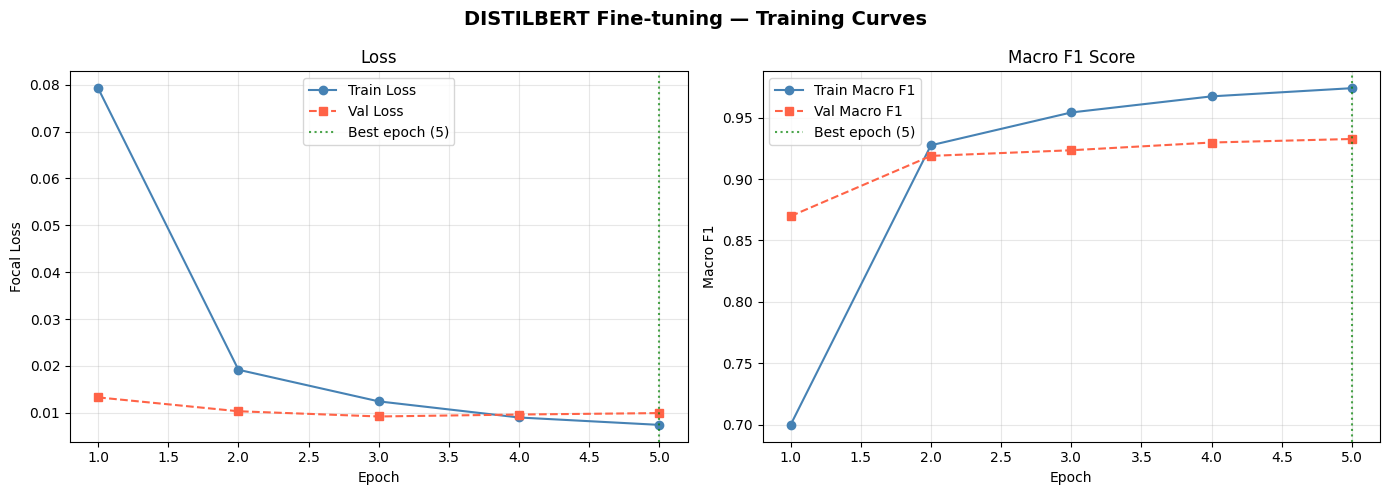

Training curves saved.


In [14]:
epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DISTILBERT Fine-tuning — Training Curves", fontsize=14, fontweight='bold')

# ── Loss ─────────────────────────────────────────────────────────────────────
axes[0].plot(x, history['train_loss'], 'o-', label='Train Loss', color='steelblue')
axes[0].plot(x, history['val_loss'],   's--', label='Val Loss',   color='tomato')
axes[0].axvline(best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Macro F1 ─────────────────────────────────────────────────────────────────
axes[1].plot(x, history['train_f1'], 'o-', label='Train Macro F1', color='steelblue')
axes[1].plot(x, history['val_f1'],   's--', label='Val Macro F1',   color='tomato')
axes[1].axvline(best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Macro F1 Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "distilbert_training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")

---
## Stage 12 · Final Evaluation on Best Checkpoint

- Reloading the best checkpoint, not the final epoch weights, ensures evaluation reflects the model at peak generalisation, not the potentially overfit last state.
- **Metrics used:**
  - **Per-class Precision / Recall / F1:** Reveals if smishing (the most dangerous class) has adequate recall.
  - **Macro F1:** Primary metric — equal weight to all 3 classes, appropriate for imbalanced multiclass.
  - **MCC (Matthews Correlation Coefficient):** Robust to imbalance; accounts for all four quadrants of the confusion matrix simultaneously.
  - **Confusion Matrix:** Visual diagnosis of systematic misclassification patterns (e.g., smishing predicted as ham).

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Best checkpoint loaded from: /content/drive/MyDrive/SMS-Phishing-Detection/Output/distilbert_output/distilbert_best_checkpoint


  Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]


Classification Report (Best DISTILBERT Checkpoint)
              precision    recall  f1-score   support

         ham     0.9990    0.9969    0.9979       969
        spam     0.8776    0.8776    0.8776        98
    smishing     0.9154    0.9297    0.9225       128

    accuracy                         0.9799      1195
   macro avg     0.9306    0.9347    0.9327      1195
weighted avg     0.9801    0.9799    0.9800      1195

Matthews Correlation Coefficient (MCC): 0.9383


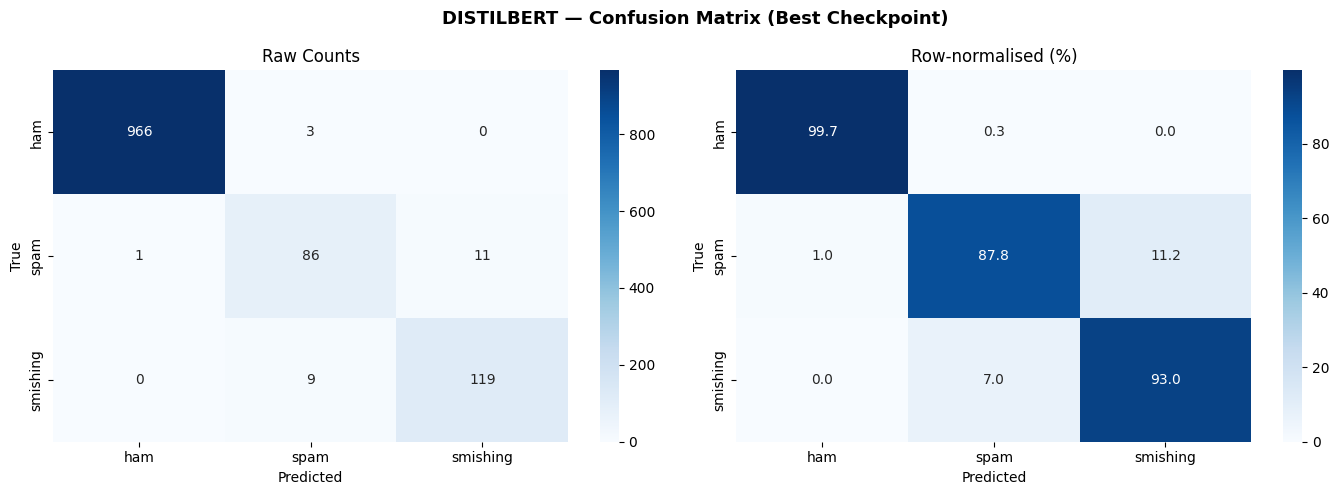

Confusion matrix saved.


In [15]:
# ── Reload best checkpoint ────────────────────────────────────────────────────
best_model = DistilBertForSequenceClassification.from_pretrained(best_ckpt_path)
best_model = best_model.to(DEVICE)
print(f"Best checkpoint loaded from: {best_ckpt_path}")

# ── Run evaluation ────────────────────────────────────────────────────────────
_, _, all_preds, all_labels = evaluate(best_model, test_loader, criterion, DEVICE)
label_names = [ID2LABEL[i] for i in range(NUM_LABELS)]

# ── Per-class report ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Classification Report (Best DISTILBERT Checkpoint)")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=label_names, digits=4))

# ── MCC ───────────────────────────────────────────────────────────────────────
mcc = matthews_corrcoef(all_labels, all_preds)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row-normalised %

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DISTILBERT — Confusion Matrix (Best Checkpoint)", fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_pct],
    ['d', '.1f'],
    ['Raw Counts', 'Row-normalised (%)']):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=label_names, yticklabels=label_names, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "distilbert_confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

---
## Stage 13 · Inference Speed Benchmarking

- The objective of this project is to evaluate the **compute-to-performance trade-off** between BERT and DistilBERT. Performance metrics alone (F1, MCC) are insufficient. Inference latency is equally critical for real-time mobile fraud detection where messages must be classified within milliseconds.
- Measuring throughput (samples/second) and mean latency per sample on the same GPU provides a direct comparison denominator for the DistilBERT notebook.
- GPU warm-up iterations are discarded to avoid cold-start CUDA initialisation overhead contaminating timing results.

In [21]:
import time

best_model.eval()
WARMUP_BATCHES  = 3
TIMING_BATCHES  = 20

# Use num_workers=0 here to avoid multiprocessing shutdown warnings in notebooks
timing_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available()
 )
timing_iter = iter(timing_loader)

# ── GPU warm-up ───────────────────────────────────────────────────────────────
with torch.no_grad():
    for _ in range(WARMUP_BATCHES):
        batch = next(timing_iter)
        _ = best_model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE),
            labels         = batch['labels'].to(DEVICE)
        )

if torch.cuda.is_available():
    torch.cuda.synchronize()

# ── Timed inference ───────────────────────────────────────────────────────────
latencies = []
with torch.no_grad():
    for _ in range(TIMING_BATCHES):
        batch = next(timing_iter)
        start = time.perf_counter()
        _ = best_model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE),
            labels         = batch['labels'].to(DEVICE)
        )
        if torch.cuda.is_available():
            torch.cuda.synchronize() # ensure GPU op is complete before recording
        latencies.append((time.perf_counter() - start) * 1000)  # ms

mean_latency = np.mean(latencies)
p95_latency  = np.percentile(latencies, 95)
throughput   = 1000.0 / mean_latency  # samples per second (batch_size=1)

print("=" * 45)
print("DISTILBERT Inference Speed Benchmark (batch_size=1)")
print("=" * 45)
print(f"  Mean latency  : {mean_latency:.2f} ms / sample")
print(f"  P95  latency  : {p95_latency:.2f} ms / sample")
print(f"  Throughput    : {throughput:.1f} samples / second")
print(f"  GPU           : {torch.cuda.get_device_name(0)}")

# ── Save benchmark results for comparison ────────────────────────────────────
benchmark_results = {
    'model'        : 'distilbert-base-uncased',
    'mean_lat_ms'  : round(mean_latency, 3),
    'p95_lat_ms'   : round(p95_latency,  3),
    'throughput'   : round(throughput,   2),
    'macro_f1'     : round(best_macro_f1, 4),
    'mcc'          : round(mcc, 4)
}
pd.DataFrame([benchmark_results]).to_csv(
    os.path.join(OUTPUT_DIR, "distilbert_benchmark.csv"), index=False
 )
print("\nBenchmark results saved to distilbert_benchmark.csv")

DISTILBERT Inference Speed Benchmark (batch_size=1)
  Mean latency  : 21.08 ms / sample
  P95  latency  : 23.54 ms / sample
  Throughput    : 47.4 samples / second
  GPU           : Tesla T4

Benchmark results saved to distilbert_benchmark.csv


---
## Stage 14 · Save Final Artefacts & Summary

Saving the full model, tokenizer, and config to Drive in HuggingFace format enables direct reloading via `from_pretrained()` for both inference and the DistilBERT comparison pipeline.

In [22]:
final_model_path = os.path.join(OUTPUT_DIR, "distilbert_final_model")
best_model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"Final model saved to: {final_model_path}")

# ── Summary table ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame([
    {"Metric"    : "Model",                     "Value": "distilbert-base-uncased"},
    {"Metric"    : "Total parameters",          "Value": f"{total_params:,}"},
    {"Metric"    : "Max sequence length",       "Value": MAX_LEN},
    {"Metric"    : "Batch size",                "Value": BATCH_SIZE},
    {"Metric"    : "Epochs trained",            "Value": best_epoch},
    {"Metric"    : "Best Val Macro F1",         "Value": f"{best_macro_f1:.4f}"},
    {"Metric"    : "MCC",                       "Value": f"{mcc:.4f}"},
    {"Metric"    : "Mean inference latency (ms)","Value": f"{mean_latency:.2f}"},
    {"Metric"    : "P95  inference latency (ms)","Value": f"{p95_latency:.2f}"},
    {"Metric"    : "Throughput (samples/s)",    "Value": f"{throughput:.1f}"},
])

print("\n" + "=" * 50)
print("DISTILBERT Training & Evaluation Summary")
print("=" * 50)
print(summary_df.to_string(index=False))

summary_df.to_csv(os.path.join(OUTPUT_DIR, "distilbert_summary.csv"), index=False)
print("\nSummary saved to distilbert_summary.csv")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved to: /content/drive/MyDrive/SMS-Phishing-Detection/Output/distilbert_output/distilbert_final_model

DISTILBERT Training & Evaluation Summary
                     Metric                   Value
                      Model distilbert-base-uncased
           Total parameters              66,955,779
        Max sequence length                     128
                 Batch size                      32
             Epochs trained                       5
          Best Val Macro F1                  0.9327
                        MCC                  0.9383
Mean inference latency (ms)                   21.08
P95  inference latency (ms)                   23.54
     Throughput (samples/s)                    47.4

Summary saved to distilbert_summary.csv
